In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv(
    r"C:\Users\FAESA C F\OneDrive\Desktop\EDA project\data\interim\cleaned_day2.csv"
)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Not Available,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [4]:
df['year'] = df['date_added'].dt.year
df['month'] = df['date_added'].dt.month
df['day'] = df['date_added'].dt.day

In [5]:
df[['year','month','day']].head()

,year,month,day
0,2021.0,9.0,25.0
1,2021.0,9.0,24.0
2,2021.0,9.0,24.0
3,2021.0,9.0,24.0
4,2021.0,9.0,24.0


# Plot Year Trend
Movies/Shows Added Over Years

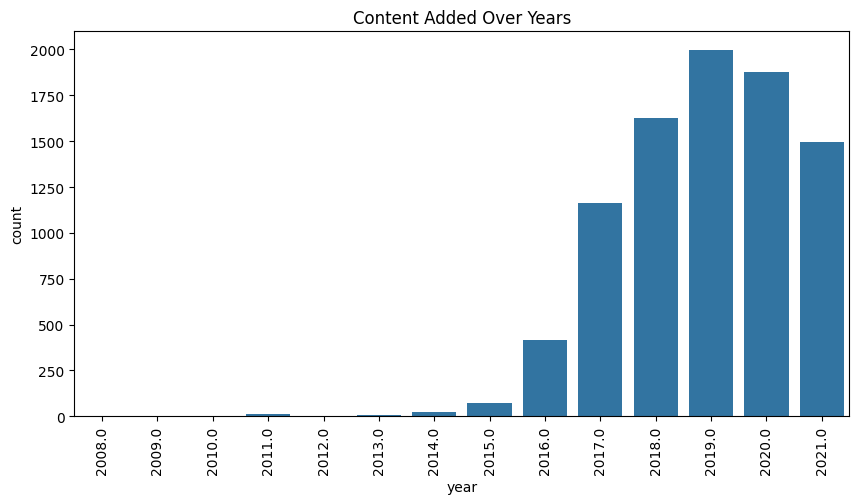

In [6]:
plt.figure(figsize=(10,5))

sns.countplot(x="year", data=df)

plt.xticks(rotation=90)

plt.title("Content Added Over Years")

plt.show()


# Plot monthly trend

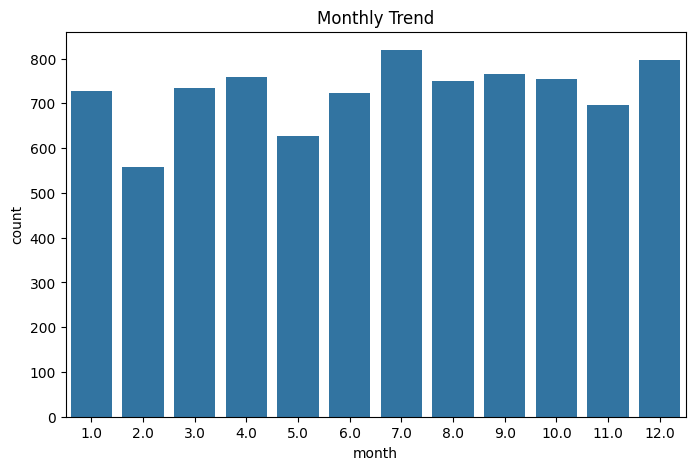

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='month',
    data=df
)

plt.title("Monthly Trend")
plt.show()

In [8]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

### Feature 1: Movie duration category

In [9]:
df['duration_group'] = pd.cut(
    df['duration_num'],
    bins=[0,60,120,300],
    labels=['Short','Medium','Long']
)
df[['duration','duration_num','duration_group']].head()

,duration,duration_num,duration_group
0,90 min,90.0,Medium
1,2 Seasons,2.0,Short
2,1 Season,1.0,Short
3,1 Season,1.0,Short
4,2 Seasons,2.0,Short


### Feature 2: Content age

In [10]:
df['content_age'] = 2026 - df['release_year']

### Feature 3: Release decade

In [11]:
df['decade'] = (df['release_year']//10)*10

### Feature 4: Old/New content

In [12]:
df['content_type'] = np.where(
    df['release_year'] > 2018,
    "New",
    "Old"
)

### Feature 5: Title length

In [13]:
df['title_length'] = df['title'].apply(len)

# Hypothesis Testing

In [14]:
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

### T-Test

#### Compare movie duration between Movies and TV Shows.

In [15]:
from scipy.stats import ttest_ind

movie = df[df['type']=="Movie"]['release_year'].dropna()
tv = df[df['type']=="Tv Show"]['release_year'].dropna()

print(len(movie), len(tv))

t, p = ttest_ind(movie, tv)

print("T-statistic:", t)
print("P-value:", p)

6131 2676
T-statistic: -17.339416624102576
P-value: 2.965941136090255e-66


In [16]:
if p < 0.05:
    print("Reject H0: Significant difference in release years")
else:
    print("Fail to reject H0: No significant difference")

Reject H0: Significant difference in release years


### ANOVA

#### Compare duration among rating groups.

In [17]:
from scipy.stats import f_oneway

groups = [
    group['release_year'].dropna().values
    for name, group in df.groupby('rating')
]

f, p = f_oneway(*groups)

print("F-statistic:", f)
print("P-value:", p)

F-statistic: 61.72005003746489
P-value: 4.104047103254141e-189


In [18]:
if p < 0.05:
    print("Reject H0: Significant difference among rating groups")
else:
    print("Fail to reject H0: No significant difference")

Reject H0: Significant difference among rating groups


### Chi-square

#### Relationship between:

Type vs Rating

In [19]:
table = pd.crosstab(
df['type'],
df['rating']
)

chi,p,dof,expected = chi2_contingency(table)

print(p)

6.277819254424652e-213


In [20]:
if p < 0.05:
    print("Reject H0: Type and Rating are related")
else:
    print("Fail to reject H0: No significant relationship between Type and Rating")

Reject H0: Type and Rating are related


## Insights

1. Movies dominate Netflix content.
2. Most content released after 2015.
3. Duration mainly medium length.
4. Recent content increased rapidly.
5. Significant relation found between rating and type.

In [21]:
df.to_csv(
r"C:\Users\FAESA C F\OneDrive\Desktop\EDA project\data\processed\final_cleaned_day4.csv",
index=False
)

print("Saved successfully")

Saved successfully
